# Placement Prediction — End-to-End ML Pipeline

Predicting whether a student gets placed based on their **CGPA** and **IQ**.

**Pipeline steps:**
1. Load & inspect data
2. Preprocessing (nulls, duplicates, column selection)
3. Exploratory Data Analysis
4. Feature/target split
5. Train/test split (reproducible)
6. Feature scaling
7. Model training & selection (cross-validation across multiple models)
8. Hyperparameter tuning
9. Final evaluation (accuracy, confusion matrix, precision/recall/F1, ROC-AUC)
10. Export the trained model for deployment


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the Data

In [8]:
df = pd.read_csv('placement.csv')
df.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [10]:
# Basic sanity checks
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (100, 4)

Missing values:
 Unnamed: 0    0
cgpa          0
iq            0
placement     0
dtype: int64

Duplicate rows: 0


## 2. Preprocessing

Use explicit column names instead of positional slicing (`iloc`) — this is more robust
if the column order in the CSV ever changes, and makes the code self-documenting.


In [11]:
# Drop the unnamed index column if present, by name (not position)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Drop exact duplicate rows, if any
df = df.drop_duplicates().reset_index(drop=True)

df.head()


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


## 3. Exploratory Data Analysis

A single scatter plot doesn't tell us much on its own — let's look at class balance,
feature distributions, outliers, and correlation before modeling.


placement
1    50
0    50
Name: count, dtype: int64


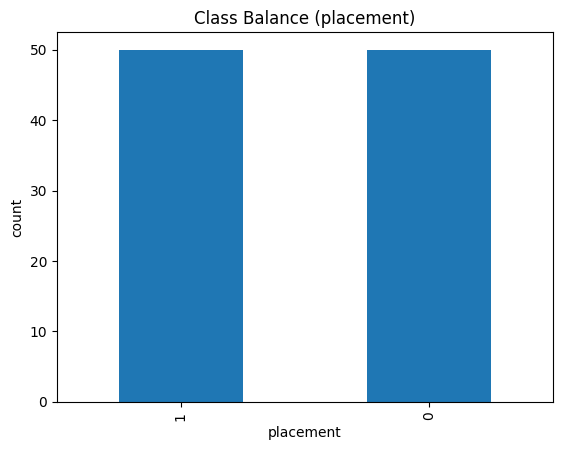

In [12]:
# Class balance
print(df['placement'].value_counts())
df['placement'].value_counts().plot(kind='bar', title='Class Balance (placement)')
plt.xlabel('placement')
plt.ylabel('count')
plt.show()


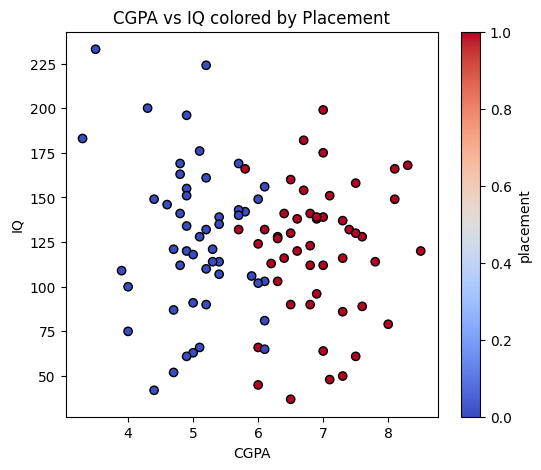

In [13]:
# Scatter plot: cgpa vs iq, colored by placement
plt.figure(figsize=(6, 5))
plt.scatter(df['cgpa'], df['iq'], c=df['placement'], cmap='coolwarm', edgecolor='k')
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('CGPA vs IQ colored by Placement')
plt.colorbar(label='placement')
plt.show()


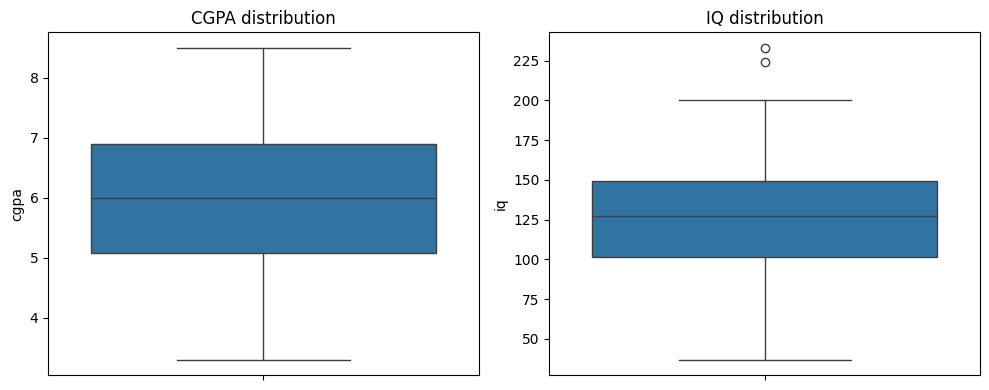

In [14]:
# Boxplots to check for outliers in each feature
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['cgpa'], ax=axes[0])
axes[0].set_title('CGPA distribution')
sns.boxplot(y=df['iq'], ax=axes[1])
axes[1].set_title('IQ distribution')
plt.tight_layout()
plt.show()


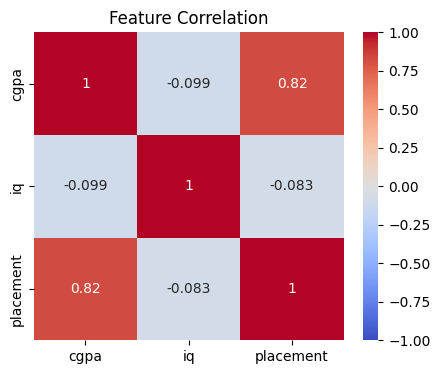

In [15]:
# Correlation heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation')
plt.show()


## 4. Extract Features and Target

In [16]:
X = df[['cgpa', 'iq']]
y = df['placement']

X.head()


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


## 5. Train/Test Split

Using a fixed `random_state` makes the split — and therefore every downstream metric —
reproducible. Without it, accuracy will vary every time the notebook is re-run.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (80, 2)
Test shape: (20, 2)


## 6. Feature Scaling

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 7. Model Selection via Cross-Validation

Rather than training a single model on a single split (and getting a possibly misleading
100% accuracy on a tiny test set), compare several classifiers using k-fold cross-validation
on the training data.


In [19]:
models = {
    'Logistic Regression': LogisticRegression(),
    'SVM (RBF)': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:20s} mean CV accuracy: {scores.mean():.3f}  (+/- {scores.std():.3f})")


Logistic Regression  mean CV accuracy: 0.912  (+/- 0.031)
SVM (RBF)            mean CV accuracy: 0.912  (+/- 0.031)
KNN                  mean CV accuracy: 0.875  (+/- 0.040)
Decision Tree        mean CV accuracy: 0.938  (+/- 0.040)


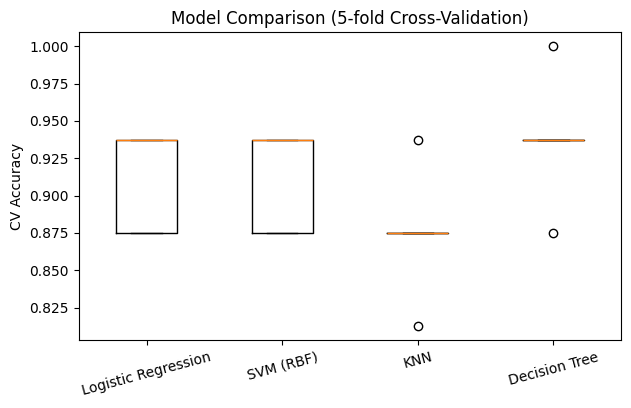

In [20]:
# Visualize the spread of CV scores per model
plt.figure(figsize=(7, 4))
plt.boxplot(cv_results.values(), tick_labels=cv_results.keys())
plt.ylabel('CV Accuracy')
plt.title('Model Comparison (5-fold Cross-Validation)')
plt.xticks(rotation=15)
plt.show()


## 8. Hyperparameter Tuning

Pick the best-performing model from the comparison above and tune it with `GridSearchCV`.
Logistic Regression is used below as an example — swap in whichever model performed best
for your data.


In [21]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy'
)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_


Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.925


## 9. Final Evaluation on the Held-Out Test Set

Accuracy alone can be misleading, especially on small or imbalanced datasets — precision,
recall, F1, and the confusion matrix give a fuller picture of what the model actually gets
right and wrong.


In [22]:
y_pred = best_model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Test Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



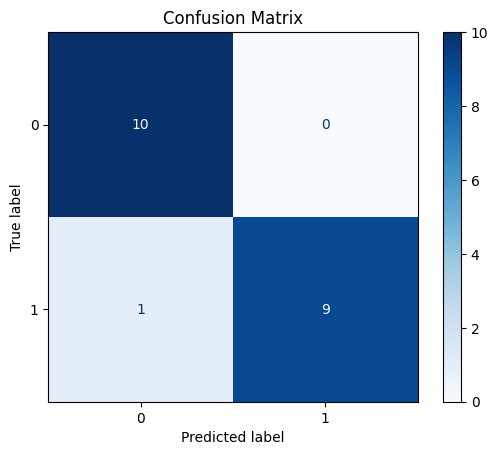

In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


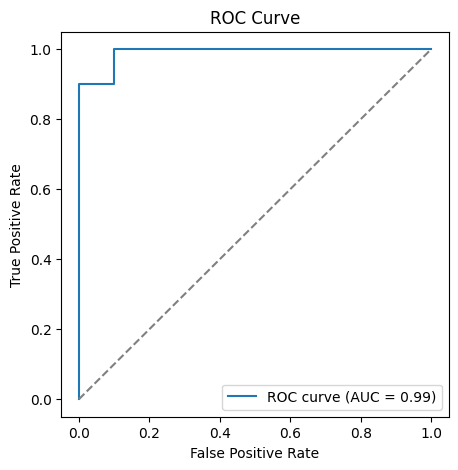

In [24]:
# ROC curve and AUC (only meaningful if the model supports predict_proba)
if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()


## 10. Decision Boundary Visualization

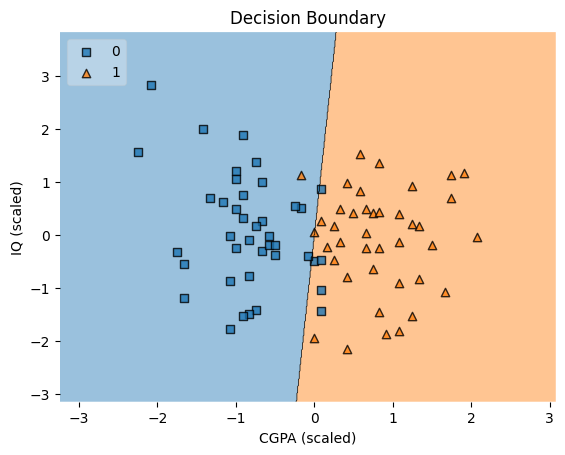

In [25]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(
    X=X_train_scaled, y=y_train.values, clf=best_model, legend=2
)
plt.xlabel('CGPA (scaled)')
plt.ylabel('IQ (scaled)')
plt.title('Decision Boundary')
plt.show()


## 11. Export the Model

Save both the trained model **and** the scaler — at inference time, new input needs to go
through the same scaling transform the model was trained on.


In [26]:
import pickle
import os

os.makedirs('model', exist_ok=True)

with open('model/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Saved model/model.pkl and model/scaler.pkl")


Saved model/model.pkl and model/scaler.pkl


## Next Step: Deployment

See `predict.py` for a small script that loads the saved model and scaler and makes
predictions on new CGPA/IQ input — this closes the loop from "trained model" to
"usable prediction," completing the end-to-end pipeline.
